DATASET LOADED SUCCESSFULLY
                                               title   country  \
0  2 room apartment 120 m² in Mediterranean Regio...    Turkey   
1              4 room villa 500 m² in Kalkan, Turkey    Turkey   
2          1 room apartment 65 m² in Antalya, Turkey    Turkey   
3             1 room apartment  in Pattaya, Thailand  Thailand   
4             2 room apartment  in Pattaya, Thailand  Thailand   

                                    location  building_construction_year  \
0               Mediterranean Region, Turkey                         NaN   
1  Kalkan, Mediterranean Region, Kas, Turkey                      2021.0   
2      Mediterranean Region, Antalya, Turkey                         NaN   
3      Chon Buri Province, Pattaya, Thailand                      2020.0   
4      Chon Buri Province, Pattaya, Thailand                      2026.0   

   building_total_floors  apartment_floor  apartment_rooms  \
0                    5.0              1.0              3

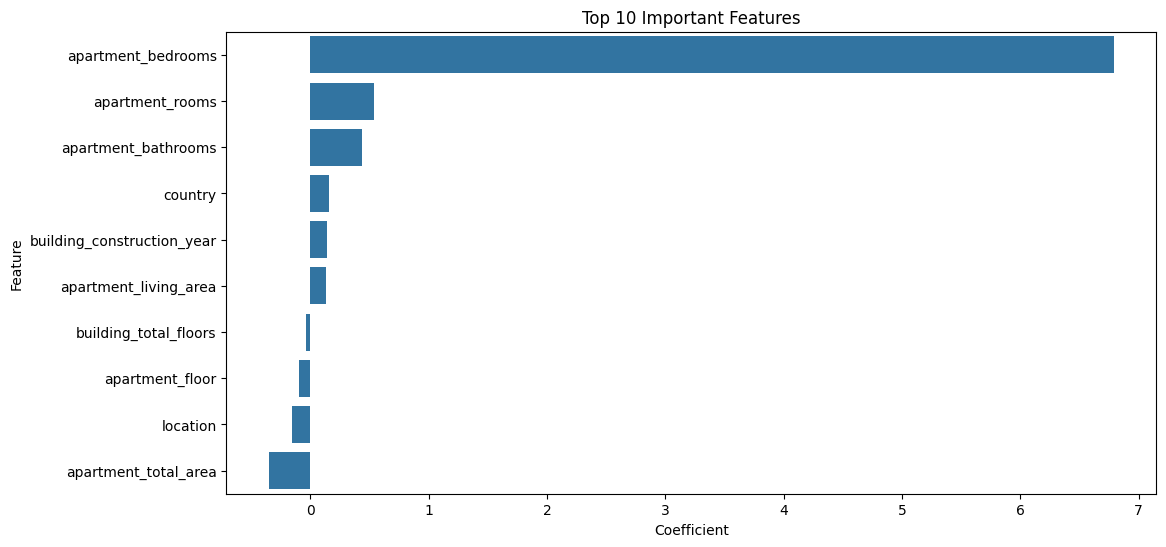

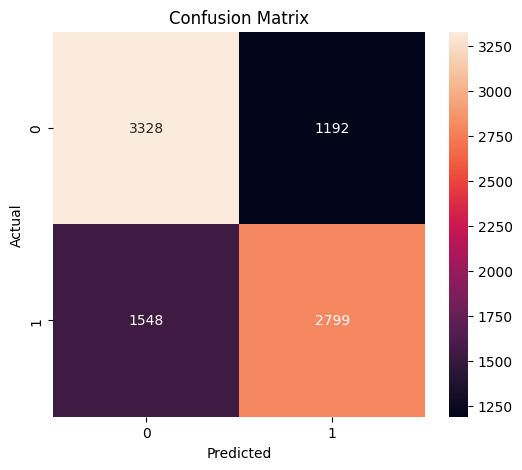


================ MODEL SAVED ================

================ MODEL LOADED ================

================ SINGLE PREDICTION ================
[0]

================ PREDICTION PROBABILITY ================
[[0.61755851 0.38244149]]

================ COUNTRY ANALYSIS ================
country
0    0.333333
1    1.000000
2    0.000000
3    0.636310
4    0.395101
5    1.000000
6    1.000000
7    0.577941
8    1.000000
9    0.000000
Name: target, dtype: float64


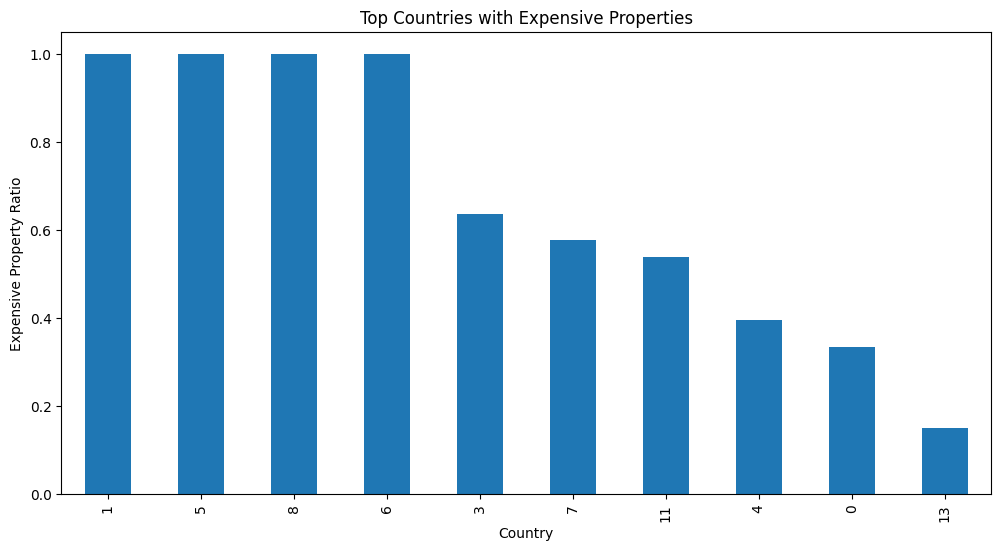

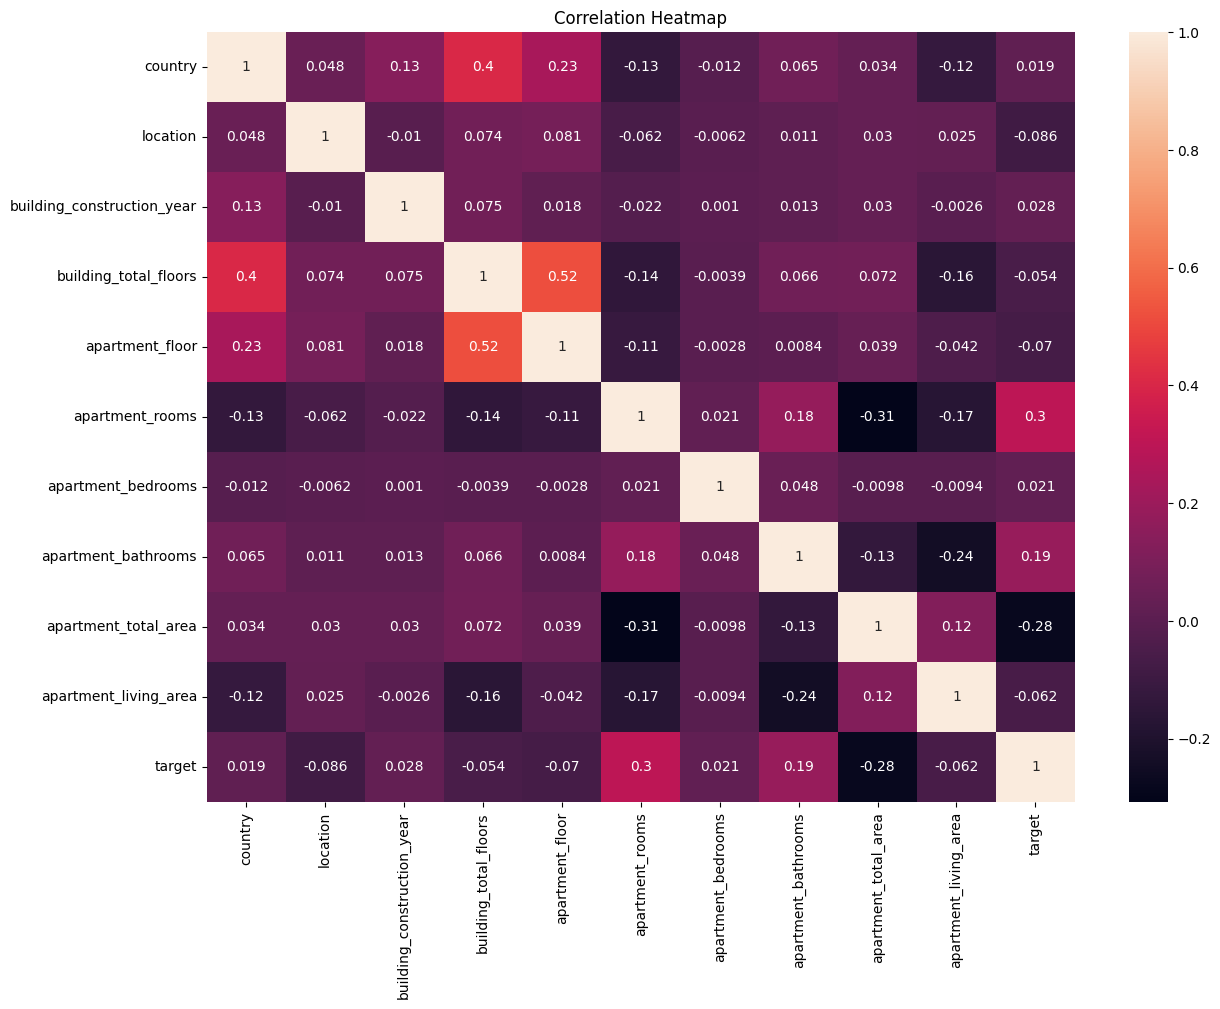

In [2]:
# ============================================================
# WORLD REAL ESTATE DATASET (147K)
# FULL ETL + LOGISTIC REGRESSION PROJECT
# CORRECT VERSION FOR Kaggle DATASET
# ============================================================

# ============================================================
# STEP 1 — IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import joblib


# ============================================================
# STEP 2 — LOAD DATASET
# ============================================================

# Load dataset
df = pd.read_csv("/content/world_real_estate_data(147k).csv")

print("DATASET LOADED SUCCESSFULLY")

# Show first 5 rows
print(df.head())


# ============================================================
# STEP 3 — CHECK COLUMN NAMES
# ============================================================

print("\n================ COLUMN NAMES ================")

print(df.columns)


# ============================================================
# STEP 4 — BASIC DATA ANALYSIS
# ============================================================

print("\n================ DATASET SHAPE ================")
print(df.shape)

print("\n================ DATASET INFO ================")
print(df.info())

print("\n================ MISSING VALUES ================")
print(df.isnull().sum())


# ============================================================
# STEP 5 — DROP UNNECESSARY COLUMNS
# ============================================================

# Remove columns not useful for ML

drop_cols = ['title', 'image', 'url']

df.drop(columns=drop_cols, inplace=True, errors='ignore')

print("\n================ REMAINING COLUMNS ================")

print(df.columns)


# ============================================================
# STEP 6 — HANDLE MISSING VALUES
# ============================================================

# Numerical columns
num_cols = df.select_dtypes(include=np.number).columns

# Fill numerical missing values using median
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())


# Categorical columns
cat_cols = df.select_dtypes(include='object').columns

# Fill categorical missing values using mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\n================ MISSING VALUES AFTER CLEANING ================")

print(df.isnull().sum())


# ============================================================
# STEP 7 — CREATE TARGET COLUMN
# ============================================================

# Logistic Regression = Classification
#
# Expensive House = 1
# Cheap House = 0

median_price = df['price_in_USD'].median()

df['target'] = (
    df['price_in_USD'] > median_price
).astype(int)

print("\n================ TARGET DISTRIBUTION ================")

print(df['target'].value_counts())


# ============================================================
# STEP 8 — REMOVE ORIGINAL PRICE COLUMN
# ============================================================

# Remove original price column

df.drop(columns=['price_in_USD'], inplace=True)

print("\n================ DATA AFTER TARGET CREATION ================")

print(df.head())


# ============================================================
# STEP 9 — ENCODE CATEGORICAL COLUMNS
# ============================================================

# Convert text into numbers
#
# Example:
# India -> 0
# USA -> 1

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("\n================ ENCODED DATASET ================")

print(df.head())


# ============================================================
# STEP 10 — SPLIT FEATURES & TARGET
# ============================================================

# Features
X = df.drop('target', axis=1)

# Target
y = df['target']

print("\n================ FEATURE SHAPE ================")
print(X.shape)

print("\n================ TARGET SHAPE ================")
print(y.shape)


# ============================================================
# STEP 11 — TRAIN TEST SPLIT
# ============================================================

# 80% Training
# 20% Testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\n================ TRAINING DATA ================")

print(X_train.shape)

print("\n================ TESTING DATA ================")

print(X_test.shape)


# ============================================================
# STEP 12 — FEATURE SCALING
# ============================================================

# Logistic Regression works better with scaling

scaler = StandardScaler()

# Fit + Transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data
X_test_scaled = scaler.transform(X_test)

print("\n================ SCALING COMPLETED ================")


# ============================================================
# STEP 13 — BUILD LOGISTIC REGRESSION MODEL
# ============================================================

lr_model = LogisticRegression(max_iter=1000)

# Train model
lr_model.fit(X_train_scaled, y_train)

print("\n================ MODEL TRAINED ================")


# ============================================================
# STEP 14 — PREDICTION
# ============================================================

# Predict test data

y_pred = lr_model.predict(X_test_scaled)

print("\n================ SAMPLE PREDICTIONS ================")

print(y_pred[:20])


# ============================================================
# STEP 15 — ACCURACY SCORE
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

print("\n================ ACCURACY ================")

print("Accuracy:", accuracy)


# ============================================================
# STEP 16 — CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

print("\n================ CONFUSION MATRIX ================")

print(cm)


# ============================================================
# STEP 17 — CLASSIFICATION REPORT
# ============================================================

print("\n================ CLASSIFICATION REPORT ================")

print(classification_report(y_test, y_pred))


# ============================================================
# STEP 18 — FEATURE IMPORTANCE
# ============================================================

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
})

importance_df = importance_df.sort_values(
    by='Coefficient',
    ascending=False
)

print("\n================ TOP IMPORTANT FEATURES ================")

print(importance_df.head(15))


# ============================================================
# STEP 19 — FEATURE IMPORTANCE VISUALIZATION
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    x='Coefficient',
    y='Feature',
    data=importance_df.head(10)
)

plt.title("Top 10 Important Features")

plt.xlabel("Coefficient")

plt.ylabel("Feature")

plt.show()


# ============================================================
# STEP 20 — CONFUSION MATRIX HEATMAP
# ============================================================

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()


# ============================================================
# STEP 21 — SAVE MODEL
# ============================================================

joblib.dump(lr_model, "real_estate_logistic.pkl")

joblib.dump(scaler, "scaler.pkl")

print("\n================ MODEL SAVED ================")


# ============================================================
# STEP 22 — LOAD MODEL
# ============================================================

loaded_model = joblib.load(
    "real_estate_logistic.pkl"
)

loaded_scaler = joblib.load(
    "scaler.pkl"
)

print("\n================ MODEL LOADED ================")


# ============================================================
# STEP 23 — SINGLE PREDICTION
# ============================================================

# Take first row

sample_data = X_test.iloc[0:1]

# Scale data

sample_scaled = loaded_scaler.transform(
    sample_data
)

# Predict

prediction = loaded_model.predict(
    sample_scaled
)

print("\n================ SINGLE PREDICTION ================")

print(prediction)

# Output:
#
# 0 = Cheap Property
# 1 = Expensive Property


# ============================================================
# STEP 24 — PREDICTION PROBABILITY
# ============================================================

probability = loaded_model.predict_proba(
    sample_scaled
)

print("\n================ PREDICTION PROBABILITY ================")

print(probability)

# Example:
#
# [[0.15 0.85]]
#
# 15% Cheap
# 85% Expensive


# ============================================================
# STEP 25 — COUNTRY ANALYSIS
# ============================================================

country_analysis = df.groupby(
    "country"
)["target"].mean()

print("\n================ COUNTRY ANALYSIS ================")

print(country_analysis.head(10))


# ============================================================
# STEP 26 — TOP COUNTRIES VISUALIZATION
# ============================================================

top_country = country_analysis.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

top_country.plot(kind='bar')

plt.title(
    "Top Countries with Expensive Properties"
)

plt.xlabel("Country")

plt.ylabel("Expensive Property Ratio")

plt.show()


# ============================================================
# STEP 27 — CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()


# ============================================================
# STEP 28 — LOGISTIC REGRESSION FORMULA
# ============================================================

# Logistic Regression predicts probability
# using sigmoid function

# Formula:
#
# P(Y=1) = 1 / (1 + e^-(z))
#
# where:
#
# z = b0 + b1x1 + b2x2 + ...

# ============================================================
# END OF PROJECT
# ============================================================